<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# Machine Learning Pipelines and GridSearchCV
Estimated time needed: **25** minutes
    

## Objectives

After completing this lab you will be able to:

- Build and evaluate a machine learning pipeline
- Implement GridSearchCV for hyperparameter tuning with crossvalidation
- Implement and optimize a complex classification pipeline using real-world data
- Extract feature importances from a trained pipeline


# 머신러닝 파이프라인 및 GridSearchCV
소요 시간: **25**분

## 목표

이 실습을 완료하면 다음을 수행할 수 있습니다.

- 머신러닝 파이프라인 구축 및 평가
- 교차 검증을 사용한 하이퍼파라미터 튜닝을 위한 GridSearchCV 구현
- 실제 데이터를 사용하여 복잡한 분류 파이프라인 구현 및 최적화
- 학습된 파이프라인에서 특징 중요도 추출

## Introduction
In machine learning workflows, the Pipeline class from Scikit-Learn is invaluable for streamlining data preprocessing and model training into a single, coherent sequence. A pipeline is essentially a sequence of data transformers that culminates with an optional final predictor. This structure enables seamless integration of preprocessing and predictive modeling, ensuring that the same data transformations applied during training are consistently applied to new data during prediction.

머신러닝 워크플로우에서 Scikit-Learn의 Pipeline 클래스는 데이터 전처리 및 모델 학습을 단일하고 일관된 시퀀스로 간소화하는 데 매우 유용합니다. 파이프라인은 기본적으로 일련의 데이터 변환 과정으로 구성되며, 선택적으로 최종 예측기로 마무리됩니다. 이러한 구조를 통해 전처리 및 예측 모델링을 원활하게 통합할 수 있으며, 학습 중에 적용된 데이터 변환이 예측 시 새로운 데이터에도 일관되게 적용되도록 보장합니다.

Each intermediate step in a pipeline must be a transformer, meaning it should implement both fit and transform methods. The final step, which is typically a predictive model, or estimator, only requires a fit method. The entire pipeline can be trained simultaneously using a method like GridSearchCV, resulting in self-contained predictor that can be used to make predictions on unseen data.


파이프라인의 각 중간 단계는 변환기 역할을 해야 하며, 즉 적합(fit) 및 변환(transform) 메서드를 모두 구현해야 합니다. 최종 단계는 일반적으로 예측 모델 또는 추정기이며, 적합 메서드만 필요합니다. 전체 파이프라인은 GridSearchCV와 같은 방법을 사용하여 동시에 학습할 수 있으며, 이를 통해 미지의 데이터에 대한 예측을 수행하는 데 사용할 수 있는 자체 포함형 예측기를 생성할 수 있습니다.

Importantly, the pipeline allows you to set the parameters of each of these steps using their names and parameter names connected by a double underscore `__`. For example, if a pipeline step is named `imputer` and you want to change its strategy, you can pass a parameter like `imputer__strategy='median'`. Additionally, steps can be entirely swapped out by assigning a different estimator or even bypassed by setting them to `'passthrough'` or `None`.

중요한 점은 파이프라인을 사용하면 각 단계의 이름과 매개변수 이름을 이중 밑줄 `__`로 연결하여 매개변수를 설정할 수 있다는 것입니다. 예를 들어 파이프라인 단계의 이름이 `imputer`이고 전략을 변경하려면 `imputer__strategy='median'`과 같이 매개변수를 전달할 수 있습니다. 또한 다른 추정기를 할당하여 단계를 완전히 교체하거나 `passthrough` 또는 `None`으로 설정하여 단계를 건너뛸 수도 있습니다.

A major advantage of using a pipeline is that it enables comprehensive cross-validation and hyperparameter tuning for all steps simultaneously. By integrating the pipeline within GridSearchCV, you can fine-tune not only the model but also the preprocessing steps, leading to optimized overall performance. Pipelines are essential for scenarios where preprocessing involves estimators performing operations like scaling, encoding categorical variables, imputing missing values, and dimensionality reduction. Pipelines ensure these steps are reproducibly applied to both training and test data.


파이프라인 사용의 주요 이점은 모든 단계에 걸쳐 포괄적인 교차 검증과 하이퍼파라미터 튜닝을 동시에 수행할 수 있다는 것입니다. GridSearchCV에 파이프라인을 통합하면 모델뿐만 아니라 전처리 단계까지 세밀하게 조정할 수 있어 전반적인 성능을 최적화할 수 있습니다. 파이프라인은 전처리 과정에서 스케일링, 범주형 변수 인코딩, 결측값 대체, 차원 축소와 같은 연산을 수행하는 추정기가 필요한 시나리오에 필수적입니다. 파이프라인을 통해 이러한 단계들이 훈련 데이터와 테스트 데이터 모두에 재현 가능하게 적용될 수 있습니다.

In this lab you will:
- Generate synthetic data for running targeted experiments using scikit-learn
- Train and evaluate a KNN classification model using a pipeline
- Tune model hyperparameters using a pipeline within a cross-validation grid search
- Build a more complex random forest classification pipeline using real-world data
- Extract the feature importances from the trained pipeline

Your goal in this lab is to learn how to build and optimize a complex machine learning model using a pipeline and crossvalidation to tune its hyperparameters.

The Practice Project, which follows next, is more hands-on. There you will participate by completing code segments and formulating responses to more open-ended questions.
The better you understand this lab, the easier the Practice Project and Final Project will be for you.

이 실습에서는 다음을 수행합니다.
- scikit-learn을 사용하여 특정 실험을 위한 합성 데이터를 생성합니다.
- 파이프라인을 사용하여 KNN 분류 모델을 학습하고 평가합니다.
- 교차 검증 그리드 검색 내에서 파이프라인을 사용하여 모델 하이퍼파라미터를 튜닝합니다.
- 실제 데이터를 사용하여 더 복잡한 랜덤 포레스트 분류 파이프라인을 구축합니다.
- 학습된 파이프라인에서 특징 중요도를 추출합니다.

이 실습의 목표는 파이프라인과 교차 검증을 사용하여 복잡한 머신러닝 모델을 구축하고 최적화하는 방법을 배우는 것입니다.

다음으로 이어지는 실습 프로젝트는 더욱 실질적인 내용으로 구성됩니다. 실습 프로젝트에서는 코드 세그먼트를 완성하고 보다 개방형 질문에 대한 답변을 작성하게 됩니다.

이 실습을 잘 이해할수록 실습 프로젝트와 최종 프로젝트를 더 쉽게 수행할 수 있습니다.

## Import the required libraries


First, to make sure that the required libraries are available, run the following cell.


In [1]:
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3
!pip install seaborn==0.13.2


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


Now, you can import the required libraries and relevant functions.


In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.metrics import confusion_matrix

## Train a model using a pipeline
We'll start with an example of building a pipeline, fitting it to the Iris data, and evaluating its accuracy.
## 파이프라인을 사용하여 모델 학습
먼저 파이프라인을 구축하고, Iris 데이터에 맞춰 학습시키고, 정확도를 평가하는 예제를 살펴보겠습니다.

### Load the Iris data set


In [3]:
data = load_iris()
X, y = data.data, data.target
labels = data.target_names

### Instantiate a pipeline consisting of StandardScaler, PCA, and KNeighborsClassifier


In [4]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),       # Step 1: Standardize features
    ('pca', PCA(n_components=2),),       # Step 2: Reduce dimensions to 2 using PCA
    ('knn', KNeighborsClassifier(n_neighbors=5,))  # Step 3: K-Nearest Neighbors classifier
])

### Exercise 1. Split the data into training and test sets
Be sure to stratify the target.

### 연습 1. 데이터를 훈련 세트와 테스트 세트로 분할하세요.
목표 변수를 층화하는 것을 잊지 마세요.

In [6]:
# Enter your code here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

<details><summary>Click here for the solution</summary>
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
</details>


### Fit the pipeline on the training set
The pipeline consists of a sequence of three estimators, and should be viewed as the machine learning model we are training and testing.  
Let's go ahead and fit the model to the training data and evaluate its accuracy.


### 훈련 데이터셋에 파이프라인 적용
파이프라인은 세 개의 추정기로 구성된 일련의 과정이며, 우리가 훈련하고 테스트할 머신러닝 모델로 볼 수 있습니다.
이제 모델을 훈련 데이터에 적용하고 정확도를 평가해 보겠습니다.

In [7]:
pipeline.fit(X_train, y_train)

# Measure the pipeline accuracy on the test data
test_score = pipeline.score(X_test, y_test)
print(f"{test_score:.3f}")

0.900


### Get the model predictions


In [8]:
y_pred = pipeline.predict(X_test)

### Exercise 2. Generate the confusion matrix for the KNN model and plot it


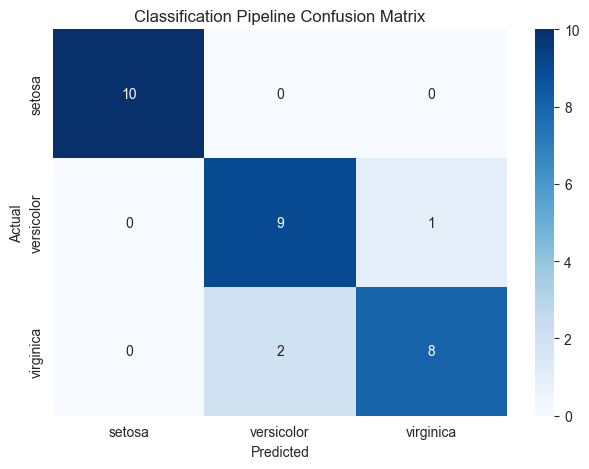

In [16]:
# Enter your code here
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a single plot for the confusion matrix
plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d',
            xticklabels=labels, yticklabels=labels)

# Set the title and labels
plt.title('Classification Pipeline Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.show()

<details><summary>Click here for the solution</summary>
    
```python
# generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a plot for the confusion matrix
plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d',
            xticklabels=labels, yticklabels=labels)

# Set the title and labels
plt.title('Classification Pipeline Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.show()
```
</details>


### Exercise 3. Describe the errors made by the model.

### 연습문제 3. 모델이 범한 오류를 설명하세요.

<details><summary>Click here for the solution</summary>
The model incorectly classified two viginica irises as versicolor, and one versicolor as virginica. Not bad, only three classification errors out of 30 irises on our first attempt! 
모델이 viginica 붓꽃 두 개를 versicolor로, versicolor 한 개를 virginica로 잘못 분류했습니다. 첫 시도에서 30개의 붓꽃 중 분류 오류가 세 개밖에 없으니 나쁘지 않네요!
</details>


## Tune hyperparameters using a pipeline within cross-validation grid search
We created a model but haven't yet attempted to optimize its performance.  Let's see if we can do better.
Recall that it would be a mistake to keep running the model over and over again with different hyperparamters to find the best one.  
You would effectively be overfiiting the model to your test data set.  
The correct way to handle this tuning is to use cross validation. 

Let's see how it works, using the same data set.

## 교차 검증 그리드 검색 내 파이프라인을 사용하여 하이퍼파라미터 튜닝
모델을 생성했지만 아직 성능 최적화를 시도하지 않았습니다. 더 나은 결과를 얻을 수 있는지 살펴보겠습니다.
최적의 하이퍼파라미터를 찾기 위해 다양한 하이퍼파라미터로 모델을 계속해서 실행하는 것은 잘못된 접근 방식임을 기억하세요.
이렇게 하면 모델이 테스트 데이터 세트에 과적합될 수 있습니다.
이러한 튜닝을 올바르게 처리하는 방법은 교차 검증을 사용하는 것입니다.

동일한 데이터 세트를 사용하여 어떻게 작동하는지 살펴보겠습니다.

### Instantiate the pipeline
We'll preprocess the data by scaling it and transforming it onto a to-be-determined number of principle components, follow that up with a KNN model classifier, and combine these estimators into a pipeline. We'll then optimize the pipeline using crossvalidation over a hyperparameter grid search. This will allow us find the best model for the set of trial hyperparamters.


### 파이프라인 인스턴스화
데이터를 스케일링하고, 결정된 개수의 주성분으로 변환하여 전처리한 다음, KNN 모델 분류기를 사용하여 추정값을 도출하고, 이러한 추정기들을 파이프라인으로 결합합니다. 그 후, 하이퍼파라미터 그리드 탐색을 통한 교차 검증으로 파이프라인을 최적화합니다. 이를 통해 다양한 하이퍼파라미터에 대한 최적의 모델을 찾을 수 있습니다.

In [17]:
# make a pipeline without specifying any parameters yet
pipeline = Pipeline(
                    [('scaler', StandardScaler()),
                     ('pca', PCA()),
                     ('knn', KNeighborsClassifier()) 
                    ]
                   )

### Define a model parameter grid to search over
### 검색할 모델 매개변수 그리드를 정의합니다.

In [18]:
# Hyperparameter search grid for numbers of PCA components and KNN neighbors
param_grid = {'pca__n_components': [2, 3],
              'knn__n_neighbors': [3, 5, 7]
             }

### Choose a cross validation method
To ensure the target is stratified, we can use scikit-learn's `StratifiedKFold` cross-validation class.


### 교차 검증 방법 선택
타겟이 계층화되었는지 확인하기 위해 scikit-learn의 `StratifiedKFold` 교차 검증 클래스를 사용할 수 있습니다.

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Exercise 4. Determine the best parameters
Pass your `pipeline`, `param_grid`, and the `StratifiedKFold` cross validation method to `GridSearchCV` 


In [20]:
# Enter your code here 
best_model = GridSearchCV(estimator=pipeline,
                          param_grid=param_grid,
                          cv=cv,
                          scoring='accuracy',
                          verbose=2
                         )

<details><summary>Click here for the solution</summary>
    
```python
best_model = GridSearchCV(estimator=pipeline,
                          param_grid=param_grid,
                          cv=cv,
                          scoring='accuracy',
                          verbose=2
                         )
```


### Fit the best `GridSearchCV` model to the training data


In [21]:
best_model.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=5, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=5, pca__n_c

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [3, 5, 7],
                         'pca__n_components': [2, 3]},
             scoring='accuracy', verbose=2)

Go ahead and explore the `GridSearchCV` graphic that describes your estimator's structure, including the hyperparameters found for the best estimator.
You can get specific help on each components by clicking on its question mark.


최적의 추정기에 대해 찾은 하이퍼파라미터를 포함하여 추정기의 구조를 설명하는 `GridSearchCV` 그래픽을 살펴보세요.
각 구성 요소의 물음표를 클릭하면 자세한 도움말을 볼 수 있습니다.

### Exercise 5. Evaluate the accuracy of the best model on the test set


In [22]:
# Enter your code here
test_score = best_model.score(X_test, y_test)
print(f"{test_score:.3f}")

0.933


<details><summary>Click here for the solution</summary>
    
```python
test_score = best_model.score(X_test, y_test)
print(f"{test_score:.3f}")
```


We've made a great accuracy improvement from 90% to 93%.


### Display the best parameters


In [23]:
best_model.best_params_

{'knn__n_neighbors': 3, 'pca__n_components': 3}

### Plot the confusion matrix for the predictions on the test set


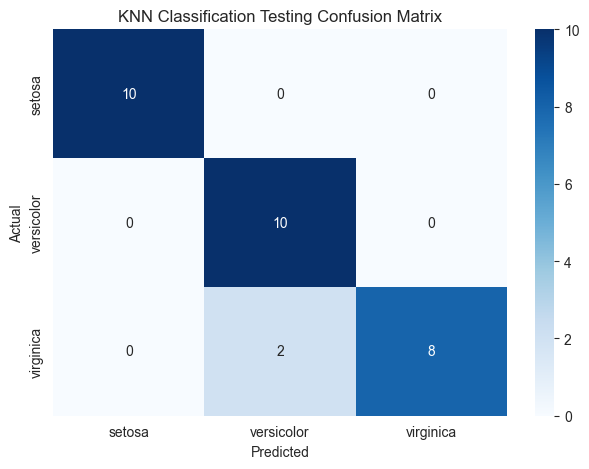

In [24]:
y_pred = best_model.predict(X_test)

# Generate the confusion matrix for KNN
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a single plot for the confusion matrix
plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d',
            xticklabels=labels, yticklabels=labels)

# Set the title and labels
plt.title('KNN Classification Testing Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.show()


That's impressive, only two errors where the predictions were Versicolor but the iris was actually a Virginica.

That conludes the lab. You are now equipped with an advanced methodolgy for building sophisticated machine learning models from the ground up. Still, there is much to learn of course. Digging into the rich set of examples from scikit-learn's website is a must. The help documentation is also fantastic. You'll learn something every time you look for certain. Of course, there is no substitude for gaining experience through practice.

Now it's time to roll up your sleeves and dive into a hands-on Practice Project.



정말 인상적이네요. 예측값이 Versicolor였는데 실제 붓꽃은 Virginica였던 오류가 단 두 개뿐이라니 말입니다.

이것으로 실습을 마칩니다. 이제 여러분은 정교한 머신러닝 모델을 처음부터 구축하는 고급 방법론을 갖추게 되었습니다. 물론 아직 배울 것이 많습니다. scikit-learn 웹사이트의 풍부한 예제들을 살펴보는 것은 필수입니다. 도움말 문서도 훌륭합니다. 찾아볼 때마다 새로운 것을 배우게 될 것입니다. 물론 실습을 통해 얻는 경험을 대신할 수는 없습니다.

이제 소매를 걷어붙이고 실제 실습 프로젝트에 뛰어들 시간입니다.

### Congratulations! You've made it this far and are now equipped to complete your Practice Project in preparation for your final project!

## Author

<a href="https://www.linkedin.com/in/jpgrossman/" target="_blank">Jeff Grossman</a>

### Other Contributor(s)

<a href="https://www.linkedin.com/in/abhishek-gagneja-23051987/" taget="_blank">Abhishek Gagneja</a>


<!-- ## Changelog

| Date | Version | Changed by | Change Description |
|:------------|:------|:------------------|:---------------------------------------|
| 2024-11-20 | 1.0  | Jeff Grossman    | Create lab |

 -->
<h3 align="center"> © IBM Corporation. All rights reserved. <h3/>
